In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../src/etl")
from db_connection import engine

df_scored=pd.read_parquet("../data/processed/df_scored.parquet")

events_df=pd.read_sql("SELECT * FROM events", engine)

print(df_scored.shape)
print(events_df.shape)


(446306, 20)
(109371, 10)


In [4]:
downtime_events=events_df[events_df["status"].isin(["Stop", "Warning", "Communication"])].copy()

window = pd.Timedelta("72h")
lead_times =[]

for _, event in downtime_events.iterrows(): #We search row by row anomalies between a 24h gap
    anomalies_before = df_scored[
        (df_scored["turbine_id"] == event["turbine_id"]) &
        (df_scored["anomaly"] == -1) &
        (df_scored["ts"] >= event["ts_start"] - window) &
        (df_scored["ts"] < event["ts_start"])
    ]
    if not anomalies_before.empty:
        lead_times.append(event["ts_start"] - anomalies_before["ts"].min())     #Choose the first anomaly
    else:
        lead_times.append(pd.NaT)

downtime_events["lead_time"] =lead_times
downtime_events["lead_time"].describe()

count                      2636
mean     2 days 04:15:18.606221
std      0 days 22:09:50.112464
min             0 days 00:00:11
25%             1 days 19:12:13
50%             2 days 13:00:39
75%             2 days 21:53:19
max             3 days 00:00:00
Name: lead_time, dtype: object

In [5]:
window = pd.Timedelta("24h")
records = []

for _, event in downtime_events.iterrows():
    readings = df_scored[
        (df_scored["turbine_id"] == event["turbine_id"]) &
        (df_scored["ts"] >= event["ts_start"] - window) &
        (df_scored["ts"] < event["ts_start"])
    ]
    hours_before = ((event["ts_start"] - readings["ts"]).dt.total_seconds() / 3600).astype(int)
    records.append(pd.DataFrame({"hours_before": hours_before, "anomaly": readings["anomaly"]}))

epoch_df = pd.concat(records, ignore_index=True)

anomaly_rate_by_hour = epoch_df.groupby("hours_before")["anomaly"].apply(lambda x: (x == -1).mean())
baseline_rate = (df_scored["anomaly"] == -1).mean()

print(f"Baseline anomaly rate: {baseline_rate:.1%}")
anomaly_rate_by_hour

Baseline anomaly rate: 7.2%


hours_before
0     0.509101
1     0.425483
2     0.368824
3     0.302315
4     0.258476
5     0.219223
6     0.190403
7     0.163981
8     0.149459
9     0.140979
10    0.128628
11    0.121503
12    0.113590
13    0.117254
14    0.117706
15    0.124386
16    0.130743
17    0.134705
18    0.136148
19    0.139710
20    0.136503
21    0.136516
22    0.136133
23    0.134530
24    0.095238
Name: anomaly, dtype: float64

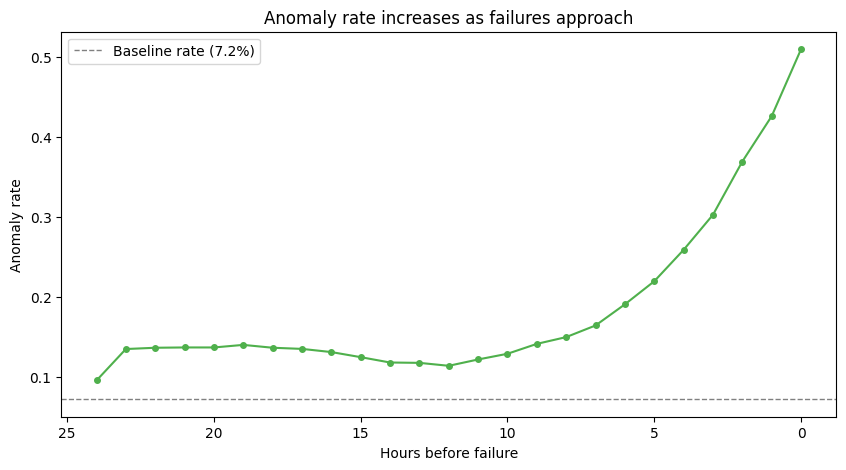

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(anomaly_rate_by_hour.index, anomaly_rate_by_hour.values,
        color="#4FB04C", marker="o", markersize=4, linewidth=1.5)

ax.axhline(baseline_rate, color="gray", linewidth=1, linestyle="--",
           label=f"Baseline rate ({baseline_rate:.1%})")

ax.invert_xaxis()
ax.set_xlabel("Hours before failure")
ax.set_ylabel("Anomaly rate")
ax.set_title("Anomaly rate increases as failures approach")
ax.legend()
plt.show()

## Lead time analysis: conclusions

**First attempt (discarded):** I first measured "time until the earliest anomaly found within a fixed window before each failure" (24h, then 72h). This turned out to be a flawed metric: the result kept growing with the window size (median lead time went from ~19h at a 24h window to ~2.5 days at a 72h window), and the max always landed exactly on the window's edge. This is a sign of a base-rate artifact: since the model flags ~7% of all readings as anomalous everywhere, looking further back just makes it more likely to stumble on unrelated noise, not a real early warning signal.

**Corrected approach:** instead, I measured the anomaly rate per hour-before-failure, averaged across all downtime events, and compared it to the overall baseline anomaly rate (7.2%).

**Result:** the anomaly rate rises steadily as failures approach: it stays around 12-14% (roughly 2x baseline) from 12 to 24 hours before the failure, and climbs sharply to 51% (about 7x baseline) in the hour right before it. This is a genuine early-warning signal, not noise: risk starts showing up nearly a full day ahead, and becomes very strong in the final hours.

This makes physical sense: turbines rarely fail instantly, most failures are preceded by a gradual degradation (rising temperatures, abnormal power output) that accumulates until the actual stop. The model picks up on this drift as the readings move further from what it learned as normal operation.

In [7]:
stray_anomalies = df_scored[(df_scored["anomaly"] == -1) & (df_scored["is_downtime"] == 0)].copy()

events_sorted = events_df.sort_values("ts_start").reset_index(drop=True)
tolerance = pd.Timedelta("1h")

explained_parts = []
for turbine_id in stray_anomalies["turbine_id"].unique():
    s = stray_anomalies[stray_anomalies["turbine_id"] == turbine_id]
    e = events_sorted[events_sorted["turbine_id"] == turbine_id]
    if e.empty:
        explained_parts.append(pd.Series(False, index=s.index))
        continue

    merged = pd.merge_asof(s[["ts"]], e[["ts_start", "ts_end"]],
                            left_on="ts", right_on="ts_start", direction="backward")

    within_duration = (merged["ts"] <= merged["ts_end"]).fillna(False)
    within_tolerance = (merged["ts"] - merged["ts_start"]).abs() <= tolerance
    explained_parts.append(pd.Series((within_duration | within_tolerance).values, index=s.index))

stray_anomalies["explained_by_event"] = pd.concat(explained_parts)
stray_anomalies["explained_by_event"].value_counts()

explained_by_event
False    20111
True      6076
Name: count, dtype: int64

In [10]:
unexplained = stray_anomalies[~stray_anomalies["explained_by_event"]]

readings_per_turbine = df_scored["turbine_id"].value_counts()
unexplained_per_turbine = unexplained["turbine_id"].value_counts()

(unexplained_per_turbine / readings_per_turbine * 100).sort_values(ascending=False)

turbine_id
WT10    6.810454
WT02    5.095889
WT07    4.715021
WT09    4.390332
WT06    4.243925
WT08    3.953507
WT05    3.897600
WT04    3.877786
WT01    3.563767
Name: count, dtype: float64

In [11]:
print("Unexplained anomalies:")
print(unexplained["wind_speed_avg"].describe())

print("\nAll readings:")
print(df_scored["wind_speed_avg"].describe())

Unexplained anomalies:
count    20111.000000
mean         9.098735
std          7.216446
min          0.142825
25%          2.483005
50%          7.963534
75%         14.320108
max         25.658411
Name: wind_speed_avg, dtype: float64

All readings:
count    446306.000000
mean          7.398596
std           4.193508
min           0.142825
25%           4.381811
50%           6.501268
75%           9.527435
max          27.433662
Name: wind_speed_avg, dtype: float64


In [12]:
low_wind = (unexplained["wind_speed_avg"] < 3).mean()
high_wind = (unexplained["wind_speed_avg"] > 20).mean()

low_wind_all = (df_scored["wind_speed_avg"] < 3).mean()
high_wind_all = (df_scored["wind_speed_avg"] > 20).mean()

print(f"Unexplained: {low_wind:.1%} below 3 m/s, {high_wind:.1%} above 20 m/s")
print(f"All readings: {low_wind_all:.1%} below 3 m/s, {high_wind_all:.1%} above 20 m/s")


Unexplained: 33.0% below 3 m/s, 14.1% above 20 m/s
All readings: 11.5% below 3 m/s, 1.3% above 20 m/s


In [18]:
df_scored = df_scored.sort_values(["turbine_id", "ts"]).reset_index(drop=True)
df_scored["is_anomaly"] = (df_scored["anomaly"] == -1).astype(int)

df_scored["anomaly_persistent"] = (
    df_scored.groupby("turbine_id")["is_anomaly"]
    .transform(lambda x: x.rolling(3, min_periods=3).sum())
) >= 3

In [19]:
print("Original:", (df_scored["anomaly"] == -1).sum())
print("Persistente:", df_scored["anomaly_persistent"].sum())

pd.crosstab(df_scored["anomaly_persistent"], df_scored["is_downtime"])

Original: 32060
Persistente: 22134


is_downtime,0,1
anomaly_persistent,,
False,418332,5840
True,16768,5366


In [20]:
thresholds = df_scored["anomaly_score"].quantile([0.02, 0.05, 0.10, 0.15, 0.20]).to_dict()

for q, t in thresholds.items():
    flagged = df_scored["anomaly_score"] <= t
    recall = df_scored.loc[df_scored["is_downtime"] == 1, "anomaly_score"].le(t).mean()
    print(f"q={q:.0%} (score<={t:.3f}): {flagged.sum()} flagged, recall on downtime={recall:.1%}")


q=2% (score<=-0.088): 8927 flagged, recall on downtime=35.8%
q=5% (score<=-0.024): 22316 flagged, recall on downtime=48.6%
q=10% (score<=0.019): 44631 flagged, recall on downtime=56.3%
q=15% (score<=0.041): 66946 flagged, recall on downtime=61.9%
q=20% (score<=0.056): 89262 flagged, recall on downtime=66.7%


## Final conclusions

**The main question:** can an unsupervised model, trained only on normal turbine operation, give any useful early warning before a real failure, without ever being told what a failure looks like?

**Yes, and I can show it with numbers.** The anomaly rate is not constant over time relative to failures, it rises the closer a failure gets: about double the normal baseline (7.2%) a full day before, and 7 times the baseline in the hour right before the failure. This only shows up close to real failures, not everywhere in the dataset, which is what convinced me it's a real signal and not just noise (my first attempt at measuring this, a simple "time to earliest anomaly in a fixed window," was actually flawed for that exact reason: it kept growing the wider I made the window, which is a classic sign of picking up background noise instead of a real pattern).

**How good is it, honestly?** At face value, it catches about half of documented failures, and the rest of what it flags either matches known system warnings or falls into wind speed extremes (near cut-in and cut-out), where the reference power curve is known to be less reliable, not necessarily real faults. Checking the turbines table confirmed all 9 turbines are the same model (Senvion MM82), so this isn't a case of mixing incompatible machines.

**What I did to make it more usable, not just "more accurate":** a single anomalous reading isn't worth alerting on, so I required 3 consecutive anomalous readings (30 minutes of sustained odd behavior) before counting it as a real alert. This cut the total flagged anomalies by 31% while only losing about 4.5 percentage points of recall, a clear win for something meant to actually be used by a maintenance team without flooding them with false alarms. I also swept different score thresholds to see the full recall vs. precision trade-off instead of blindly trusting the model's default cutoff, and found the persistence-based rule lands almost exactly on the same operating point as the best threshold choice, which is a good sign that this is a real limit of what these 9 features can tell you, not an artifact of one specific method.

**Bottom line for a real use case:** this isn't a system that catches every failure or never cries wolf, but it gives a maintenance team a meaningful early signal, roughly a day of lead time, to prioritize which turbine to check before it actually stops. That's the realistic, defensible value of this project: not a perfect oracle, but a measurable improvement over having no warning at all.
